In [40]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import re
from collections import Counter
from gensim.models.phrases import Phrases, Phraser
from sklearn.feature_extraction.text import CountVectorizer


1. Charger le dataset
   - Parser le format .ft.txt
   - Extraire labels et textes
   - Vérifier intégrité

In [41]:
data = "../data/train_sample.csv"

df = pd.read_csv(data)
df.head(5)

,review,label
0,Stuning even for the non-gamer: This sound tra...,2
1,The best soundtrack ever to anything.: I'm rea...,2
2,Amazing!: This soundtrack is my favorite music...,2
3,Excellent Soundtrack: I truly like this soundt...,2
4,"Remember, Pull Your Jaw Off The Floor After He...",2


In [42]:
# structure des données
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   review  1000 non-null   str  
 1   label   1000 non-null   int64
dtypes: int64(1), str(1)
memory usage: 15.8 KB


2. Statistiques descriptives
   - Nombre d'avis par classe
   

In [43]:
print("Distribution des labels :")
print(df['label'].value_counts())

Distribution des labels :
label
1    538
2    462
Name: count, dtype: int64


(0.0, 621.39)

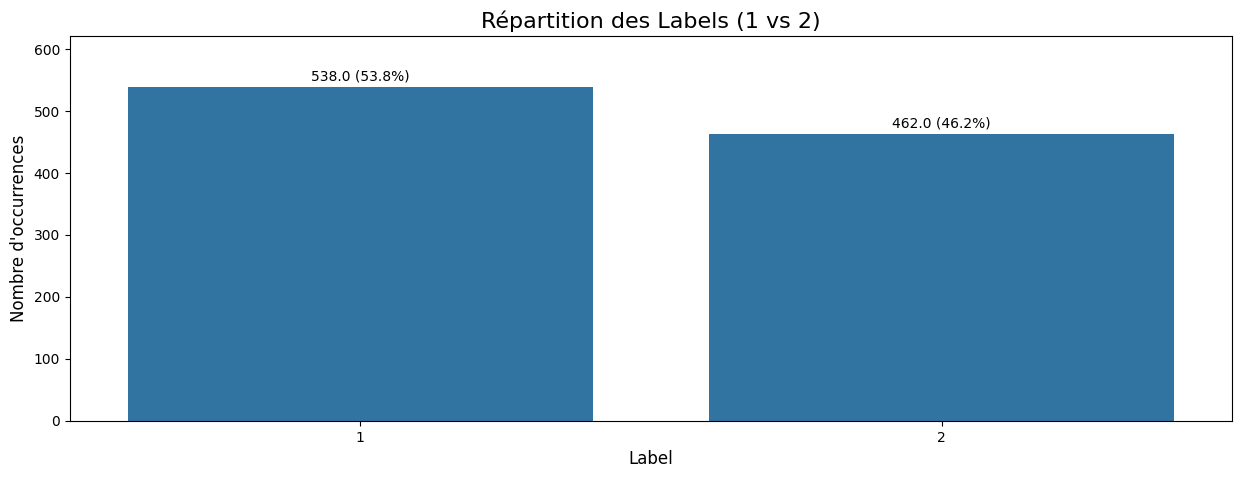

In [76]:
fig, ax = plt.subplots(figsize=(15, 5))

sns.countplot(data=df, x='label', ax=ax)

total = len(df)

for container in ax.containers:
    labels = [f'{v.get_height()} ({v.get_height()/total:.1%})' for v in container]
    ax.bar_label(container, labels=labels, label_type='edge', padding=3)

ax.set_title("Répartition des Labels (1 vs 2)", fontsize=16)
ax.set_xlabel("Label", fontsize = 12)
ax.set_ylabel("Nombre d'occurrences", fontsize = 12)
ax.set_ylim(0, ax.get_ylim()[1] * 1.1)

- Longueur moyenne, min, max

In [45]:
avg_len = df['review'].str.len().mean()
min_len = df['review'].str.len().min()
max_len = df['review'].str.len().max()

print(f"La longueur moyenne des critiques est de : {avg_len:.2f} caractères")
print(f"Le review le plus court contient {min_len} caractères")
print(f"Le review le plus long contient {max_len} caractères")

La longueur moyenne des critiques est de : 448.43 caractères
Le review le plus court contient 104 caractères
Le review le plus long contient 1014 caractères


- Distribution des longueurs par label

Text(0, 0.5, 'Fréquence')

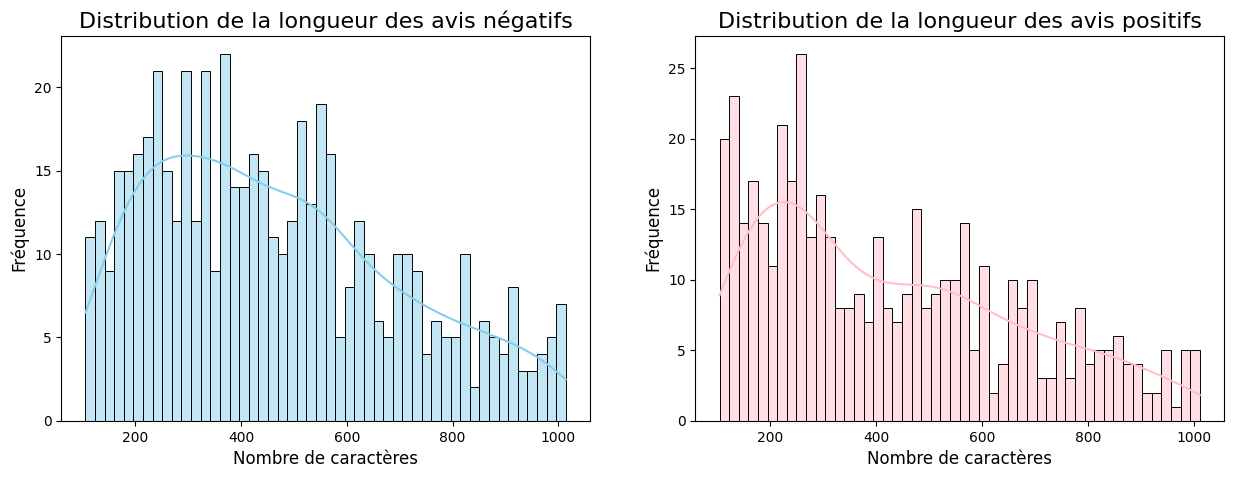

In [75]:
df['review_len'] = df['review'].str.len()

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Distribution des longueurs de texte
sns.histplot(df[df['label'] == 1]['review_len'], bins=50, kde=True, ax=ax[0], color='skyblue')
ax[0].set_title("Distribution de la longueur des avis négatifs", fontsize=16)
ax[0].set_xlabel("Nombre de caractères", fontsize=12)
ax[0].set_ylabel("Fréquence", fontsize=12)


sns.histplot(df[df['label'] == 2]['review_len'], bins=50, kde=True, ax=ax[1], color='pink')
ax[1].set_title("Distribution de la longueur des avis positifs", fontsize=16)
ax[1].set_xlabel("Nombre de caractères", fontsize=12)
ax[1].set_ylabel("Fréquence", fontsize=12)

- Vocabulaire total unique

In [47]:
vocab_size = len(set(" ".join(df['review']).lower().split()))

print(f"Nombre total de mots uniques dans le corpus : {vocab_size}")

Nombre total de mots uniques dans le corpus : 13885


3. Analyse textuelle
   - Top 50 mots positifs et négatifs

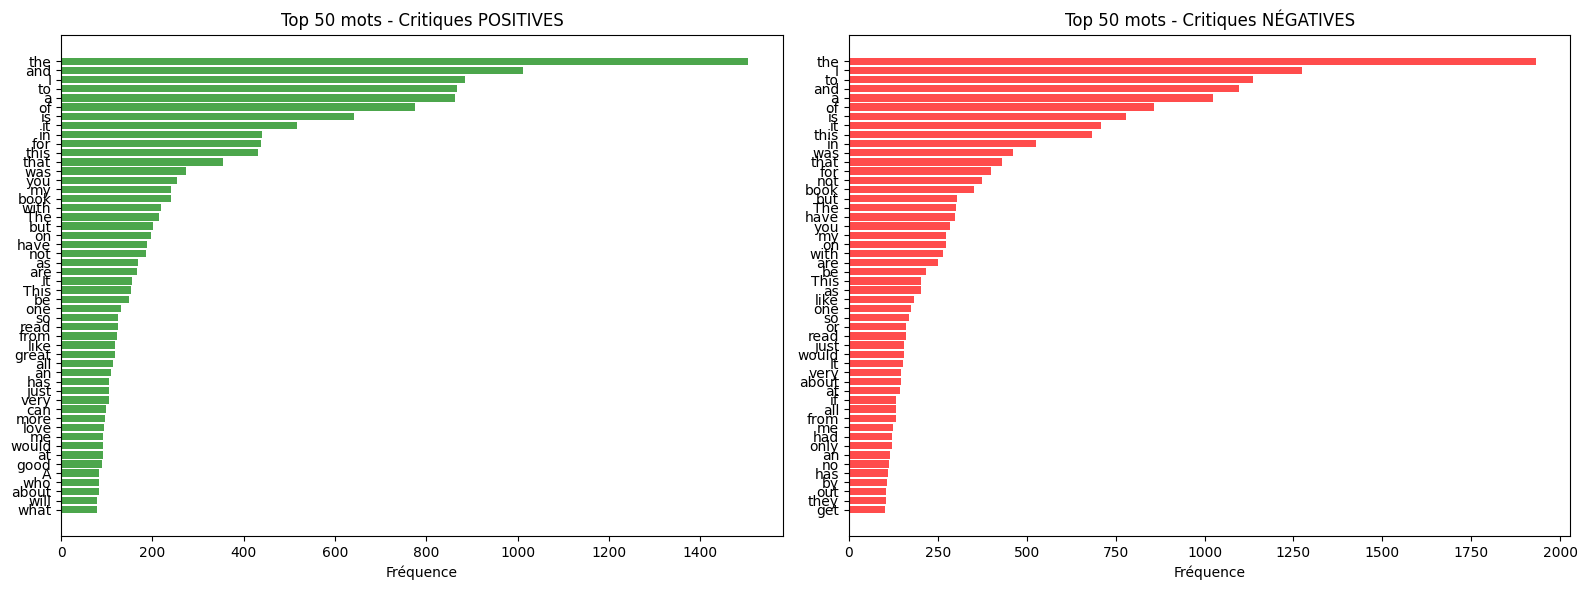

In [48]:
def get_top_words(texts, n=20):
    all_words = ' '.join(texts).split()
    word_freq = Counter(all_words)
    return word_freq.most_common(n)

# Mots positifs
positive_reviews = df[df['label'] == 2]['review']
top_positive = get_top_words(positive_reviews, 50)

# Mots négatifs
negative_reviews = df[df['label'] == 1]['review']
top_negative = get_top_words(negative_reviews, 50)


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Mots positifs
words_pos, counts_pos = zip(*top_positive)
axes[0].barh(words_pos, counts_pos, color='green', alpha=0.7)
axes[0].set_xlabel('Fréquence')
axes[0].set_title('Top 50 mots - Critiques POSITIVES')
axes[0].invert_yaxis()

# Mots négatifs
words_neg, counts_neg = zip(*top_negative)
axes[1].barh(words_neg, counts_neg, color='red', alpha=0.7)
axes[1].set_xlabel('Fréquence')
axes[1].set_title('Top 50 mots - Critiques NÉGATIVES')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

   - Bigrammes et trigrammes intéressants

In [49]:
def get_top_ngrams(corpus, n_gram_range=(2, 2), top_n=20):
    """
    Extrait les n-grammes les plus fréquents.
    n_gram_range=(2, 2) pour bigrammes, (3, 3) pour trigrammes.
    """
    # On ajoute des stop_words pour éviter "of the", "in a", etc.
    vec = CountVectorizer(ngram_range=n_gram_range, stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    
    return words_freq[:top_n]


# 1. Bigrammes Positifs (Label 2)
top_bigrams_pos = get_top_ngrams(df[df['label'] == 2]['review'], n_gram_range=(2, 2))
print("Meilleurs bigrammes positifs :")
print(top_bigrams_pos)

# 2. Bigrammes Négatifs (Label 1)
top_bigrams_neg = get_top_ngrams(df[df['label'] == 1]['review'], n_gram_range=(2, 2))
print("Meilleurs bigrammes négatifs :")
print(top_bigrams_neg)

# 3. Trigrammes (Exemple)
top_trigrams_pos = get_top_ngrams(df[df['label'] == 2]['review'], n_gram_range=(3, 3))
print("Meilleurs trigrammes positifs :")
print(top_trigrams_pos)

top_trigrams_neg = get_top_ngrams(df[df['label'] == 1]['review'], n_gram_range=(3, 3))
print("Meilleurs trigrammes négatifs :")
print(top_trigrams_neg)

Meilleurs bigrammes positifs :
[('scarlet letter', np.int64(29)), ('read book', np.int64(25)), ('year old', np.int64(20)), ('great book', np.int64(17)), ('easy read', np.int64(13)), ('book great', np.int64(13)), ('good book', np.int64(13)), ('book read', np.int64(13)), ('highly recommend', np.int64(12)), ('high school', np.int64(12)), ('great read', np.int64(10)), ('years ago', np.int64(10)), ('dark series', np.int64(10)), ('patricia cornwell', np.int64(10)), ('great product', np.int64(10)), ('night world', np.int64(9)), ('daughters darkness', np.int64(9)), ('don know', np.int64(8)), ('old daughter', np.int64(8)), ('ve read', np.int64(8))]
Meilleurs bigrammes négatifs :
[('read book', np.int64(39)), ('adam sandler', np.int64(32)), ('waste money', np.int64(24)), ('book read', np.int64(22)), ('waste time', np.int64(18)), ('year old', np.int64(17)), ('scarlet letter', np.int64(17)), ('don know', np.int64(15)), ('ve read', np.int64(15)), ('reading book', np.int64(14)), ('worst book', np.in

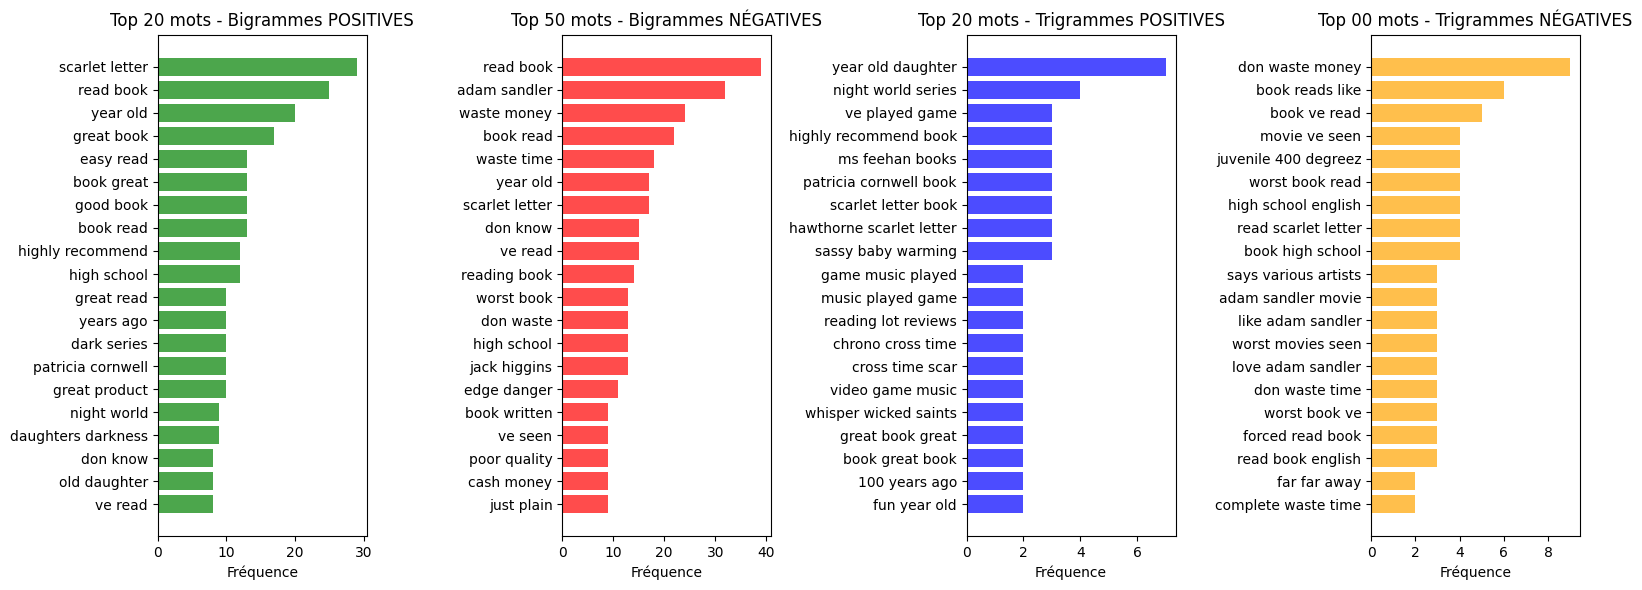

In [79]:
fig, axes = plt.subplots(1, 4, figsize=(16, 6))

# Mots positifs
words_pos, counts_pos = zip(*top_bigrams_pos)
axes[0].barh(words_pos, counts_pos, color='green', alpha=0.7)
axes[0].set_xlabel('Fréquence')
axes[0].set_title('Top 20 mots - Bigrammes POSITIVES')
axes[0].invert_yaxis()

# Mots négatifs
words_neg, counts_neg = zip(*top_bigrams_neg)
axes[1].barh(words_neg, counts_neg, color='red', alpha=0.7)
axes[1].set_xlabel('Fréquence')
axes[1].set_title('Top 50 mots - Bigrammes NÉGATIVES')
axes[1].invert_yaxis()

# Mots positifs
words_pos, counts_pos = zip(*top_trigrams_pos)
axes[2].barh(words_pos, counts_pos, color='blue', alpha=0.7)
axes[2].set_xlabel('Fréquence')
axes[2].set_title('Top 20 mots - Trigrammes POSITIVES')
axes[2].invert_yaxis()

# Mots négatifs
words_neg, counts_neg = zip(*top_trigrams_neg)
axes[3].barh(words_neg, counts_neg, color='orange', alpha=0.7)
axes[3].set_xlabel('Fréquence')
axes[3].set_title('Top 00 mots - Trigrammes NÉGATIVES')
axes[3].invert_yaxis()

plt.tight_layout()
plt.show()

   - URLs, emails, mentions

In [50]:
url_pattern = r'https?://\S+|www\.\S+'
email_pattern = r'\S+@\S+\.\S+'
mention_pattern = r'@\w+'


def count_occurrences(text, pattern):
    return len(re.findall(pattern, str(text)))


df['count_urls'] = df['review'].apply(lambda x: count_occurrences(x, url_pattern))
df['count_emails'] = df['review'].apply(lambda x: count_occurrences(x, email_pattern))
df['count_mentions'] = df['review'].apply(lambda x: count_occurrences(x, mention_pattern))

print(f"Nombre total d'URLs trouvées : {df['count_urls'].sum()}")
print(f"Nombre total d'emails trouvés : {df['count_emails'].sum()}")
print(f"Nombre total de mentions trouvées : {df['count_mentions'].sum()}")

Nombre total d'URLs trouvées : 2
Nombre total d'emails trouvés : 2
Nombre total de mentions trouvées : 2


   - Caractères spéciaux communs

In [51]:
special_char_pattern = r'[^a-zA-Z0-9\s]'

def count_special_chars(text):
    return len(re.findall(special_char_pattern, str(text)))

df['special_char_count'] = df['review'].apply(count_special_chars)

print(f"Nombre total de caractères spéciaux trouvés : {df['special_char_count'].sum()}")

Nombre total de caractères spéciaux trouvés : 15307


4. Patterns réalistes
   - Sarcasme détectable? (exemples)

In [53]:
sarcastic_examples = df[(df['label'] == 1) & (df['review'].str.contains('great|perfect', case=False))]

print(sarcastic_examples['review'].head(5))

46     Maybe I got a bad one.: My experience: I got t...
128    no technical information: this book is a great...
134    Poor instructions, but once you figure it out....
144    Product didn't match the picture/description: ...
145    Good for a laugh: I heard about this book, so ...
Name: review, dtype: str


   - Avis trop courts (bruit?)

In [64]:
too_short = df[df['review'].str.len() < 15]

print(f"Nombre d'avis potentiellement inutiles : {len(too_short)}")

Nombre d'avis potentiellement inutiles : 0


   - Avis trop longs (copier-coller?)

In [70]:
threshold_long = df['review_len'].mean() + (2 * df['review_len'].std())

too_long = df[df['review_len'] > threshold_long]

print(f"Nombre d'avis potentiellement trop long : {len(too_long)}")

Nombre d'avis potentiellement trop long : 40


   - Répétitions suspectes

In [72]:
duplicates = df.duplicated(subset=['review']).sum()

print(f"Nombre de reviews identiques : {duplicates}")

Nombre de reviews identiques : 0
